In [80]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "numpy", "scipy", "scikit-learn"])

0

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest

# load data
df = pd.read_csv('../data/household_power_consumption.txt',
                 sep=';',
                 low_memory=False,
                 na_values=['?'])

# convert date and time to datetime
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], 
                                format='%d/%m/%Y %H:%M:%S')

# set datetime as index
df = df.set_index('datetime')

# drop original date and time columns
df = df.drop(columns=['Date', 'Time'])

print(df.head())

                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

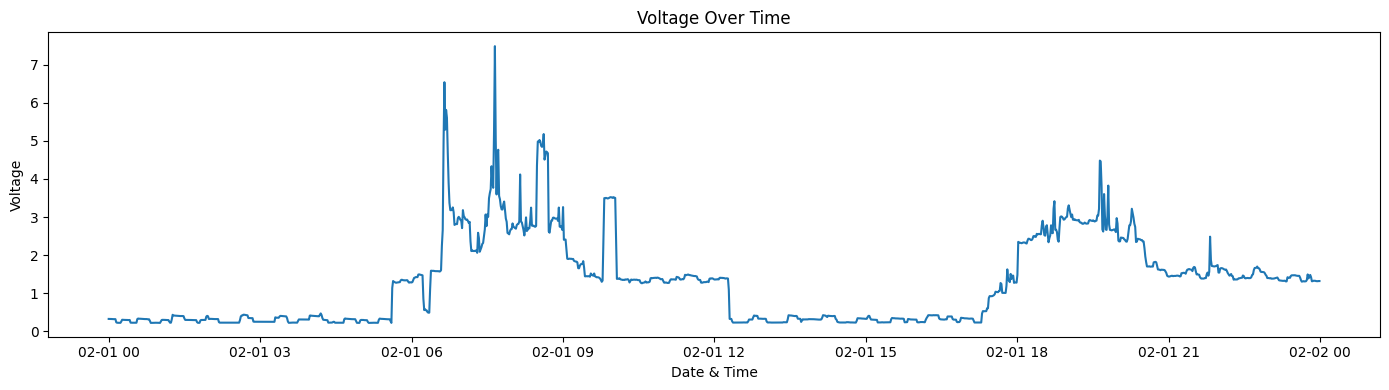

Index([5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       ...
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
      dtype='int32', name='datetime', length=2075259)


In [9]:
# filter data for a day
mask = df.loc['2007-02-01']

plt.figure(figsize=(14, 4))

# plot voltage over time for the mask
plt.plot(mask.index, mask['Global_active_power'])
plt.title('Voltage Over Time')
plt.xlabel('Date & Time')
plt.ylabel('Voltage')
plt.tight_layout()
plt.show()

print(df.index.day_of_week)

In [77]:
# calculate z-score for voltage
df['z_score'] = stats.zscore(df['Global_active_power'], nan_policy='omit') 
threshold = 3.0 

# create a boolean mask for anomalies
df["is_anomaly"] = df["z_score"] > threshold

# print anomalies
print(df[df["is_anomaly"]])

                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:34:00                4.448                  0.498   232.86   
2006-12-16 17:35:00                5.412                  0.470   232.78   
...                                  ...                    ...      ...   
2010-11-25 07:45:00                4.340                  0.284   236.40   
2010-11-25 07:46:00                4.318                  0.280   236.17   
2010-11-25 07:50:00                4.284                  0.204   237.28   
2010-11-25 07:51:00                4.440                  0.214   236.81   
2010-11-25 07:52:00                4.302                  0.194   236.84   

           

In [82]:
model = IsolationForest(contamination=0.05, random_state=42)
# contamination = what % of your data you expect to be anomalies

df["anomaly_score"] = model.fit_predict(df[["Voltage"]])

# create a boolean mask for anomalies
df["is_anomaly"] = df["anomaly_score"] < 0

# print anomalies
print(df[df["is_anomaly"]])

                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:32:00                3.668                  0.510   233.99   
2006-12-16 17:33:00                3.662                  0.510   233.86   
...                                  ...                    ...      ...   
2010-11-26 05:45:00                0.304                  0.060   247.71   
2010-11-26 05:46:00                0.290                  0.000   249.01   
2010-11-26 05:47:00                0.230                  0.046   248.46   
2010-11-26 05:48:00                0.228                  0.050   247.58   
2010-11-26 05:49:00                0.228                  0.050   247.47   

           

C:\Users\Ethan Harvey\AppData\Local\Temp\ipykernel_30680\878837046.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Ethan Harvey\Desktop\Projects\Python Anomaly Detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


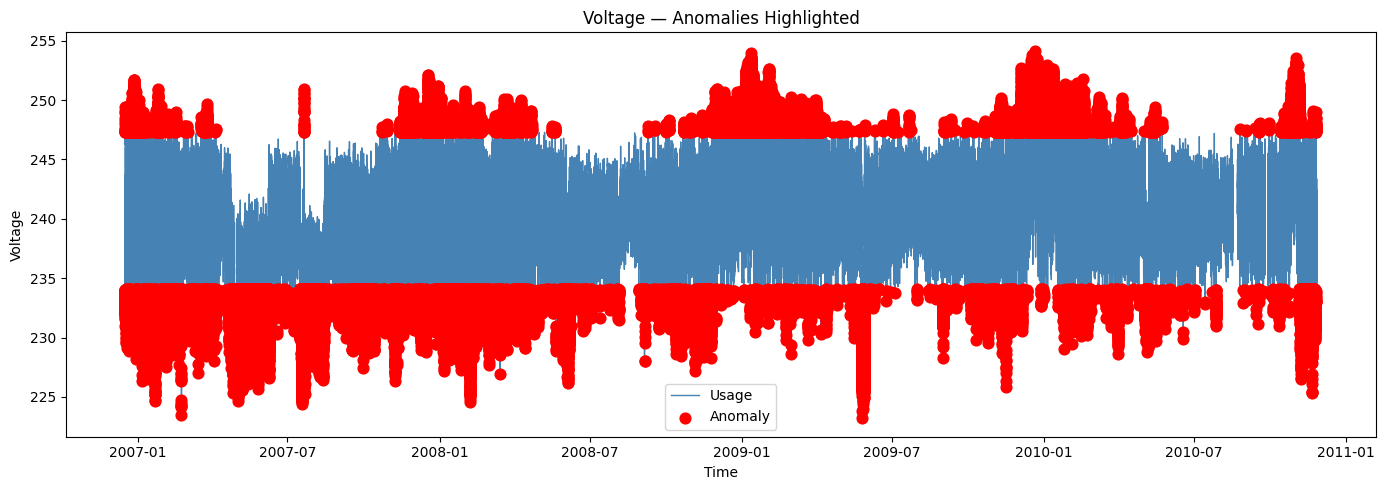

In [85]:
anomalies = df[df["is_anomaly"]]
normal = df[~df["is_anomaly"]]

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Voltage"], color="steelblue", label="Usage", linewidth=1)
plt.scatter(anomalies.index, anomalies["Voltage"],
            color="red", zorder=5, label="Anomaly", s=60)
plt.title("Voltage — Anomalies Highlighted")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.legend()
plt.tight_layout()
plt.show()